<a href="https://colab.research.google.com/github/Vishnum369/python-case-study/blob/main/unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading dataset
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers (1).csv to Mall_Customers (1) (1).csv


In [3]:
df_mall = pd.read_csv('/content/Mall_Customers (1).csv')
df_mall.head(3)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [4]:
#preprocessing

In [5]:
df_mall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df_mall.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
#for simlicity we ae cosidering only 2 columns
#annual income and spending score
x = df_mall.iloc[:,[3,4]].values

K-MEANS

In [8]:
wcss=[]
for i in range(1,11):
  kmeans = KMeans(n_clusters=i,init='k-means++')
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

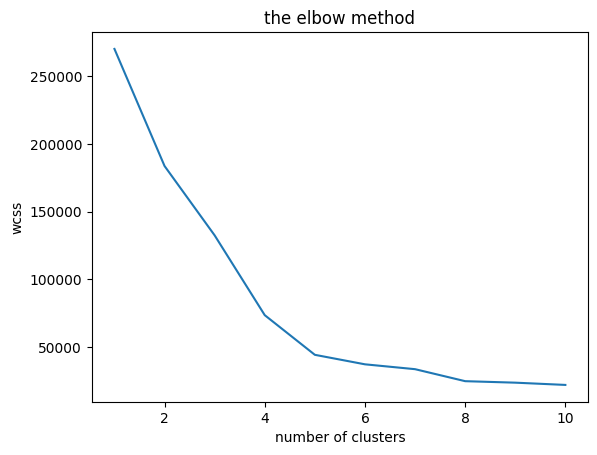

In [9]:
plt.plot(range(1,11),wcss)
plt.title('the elbow method')
plt.xlabel('number of clusters')
plt.ylabel('wcss')
plt.show()

In [10]:
#from the elbow plot , we can fix value of k as 5
#building the means clustering model
kmeans = KMeans(n_clusters=5,init='k-means++') #max_iter can be set if we need to fix the number of iterations
y_kmeans = kmeans.fit_predict(x)#output generattion

In [11]:
df_mall['cluster']=y_kmeans
df_mall.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


visual representation of clusters

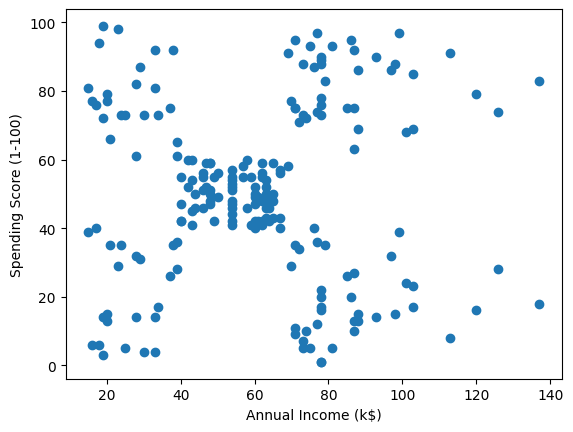

In [12]:
#before clustering
plt.scatter(df_mall['Annual Income (k$)'],df_mall['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

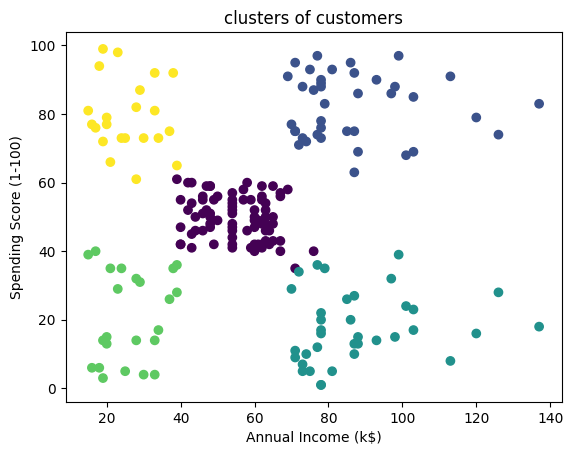

In [13]:
#after clustering
plt.scatter(df_mall['Annual Income (k$)'],
            df_mall['Spending Score (1-100)'],
            c=df_mall['cluster'])
plt.title('clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

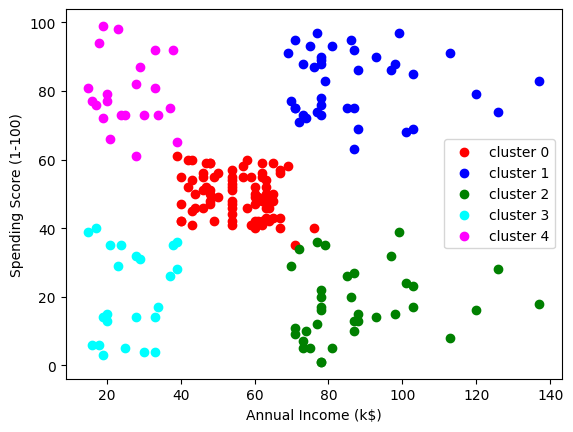

In [14]:
colors=['red','blue','green','cyan','magenta']
for i in range(5):
  cluster_data = df_mall[df_mall['cluster']==i]
  plt.scatter(df_mall[df_mall['cluster']==i]['Annual Income (k$)'],
              df_mall[df_mall['cluster']==i]['Spending Score (1-100)'],
              c=colors[i],
              label=f'cluster {i}')
  plt.legend()
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [15]:
#predict the cluster
def predict_cluster(i_annual_income,i_spending_score):
  new_data=[[i_annual_income,i_spending_score]]
  cluster=kmeans.predict(new_data)
  return cluster[0]

In [16]:
predicted_cluster = predict_cluster(50,100)
print('the values belong to the cluster',predicted_cluster)

the values belong to the cluster 4


In [ ]:
#AgglomerativeClustering

In [17]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster

In [18]:
ag_cluster = linkage(x,method='ward') #ward,singlee,centroid
#linkage matrix i.e, agglomerative cluster model

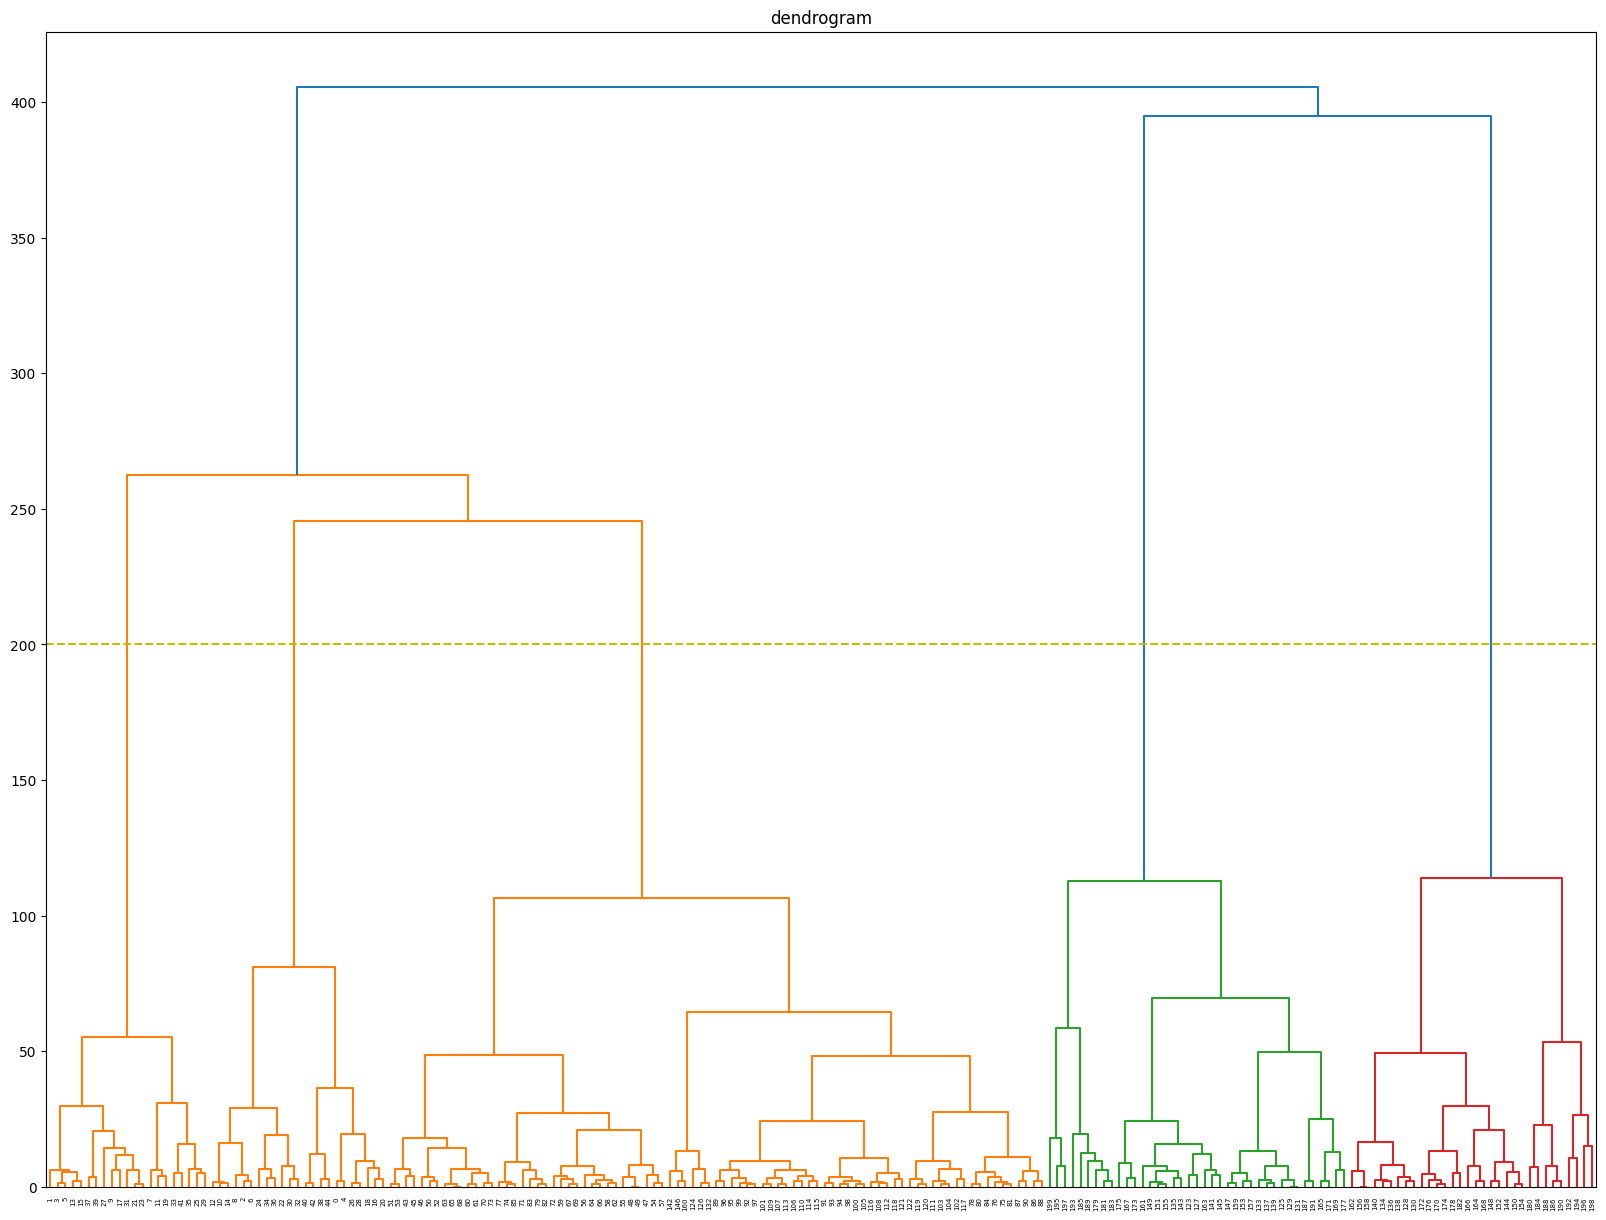

In [22]:
plt.figure(figsize=(20,15))
dendrogram(ag_cluster)
plt.axhline(y=200,color='y',linestyle='--')
plt.title('dendrogram')
plt.show()

In [23]:
cluster_labels = fcluster(ag_cluster,t=200,criterion='distance')
cluster_labels

array([2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 3,
       2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 3, 4, 5, 4, 5, 4,
       3, 4, 5, 4, 5, 4, 5, 4, 5, 4, 3, 4, 5, 4, 3, 4, 5, 4, 5, 4, 5, 4,
       5, 4, 5, 4, 5, 4, 3, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4,
       5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4,
       5, 4], dtype=int32)

In [24]:
df_mall['cluster_Agglomerative']=cluster_labels
df_mall.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster,cluster_Agglomerative
0,1,Male,19,15,39,3,2
1,2,Male,21,15,81,4,1
2,3,Female,20,16,6,3,2
3,4,Female,23,16,77,4,1
4,5,Female,31,17,40,3,2


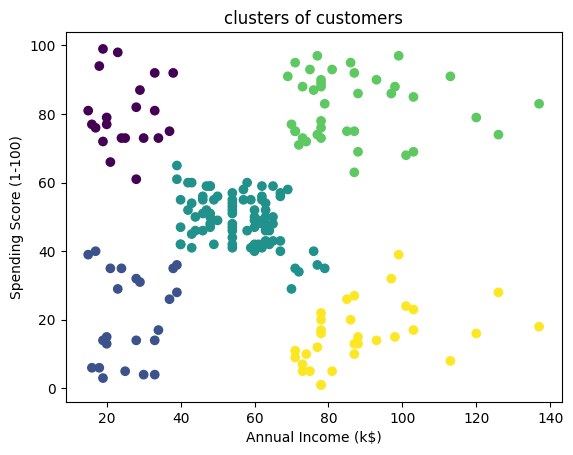

In [25]:
#after clustering
plt.scatter(df_mall['Annual Income (k$)'],
            df_mall['Spending Score (1-100)'],
            c=df_mall['cluster_Agglomerative'])
plt.title('clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

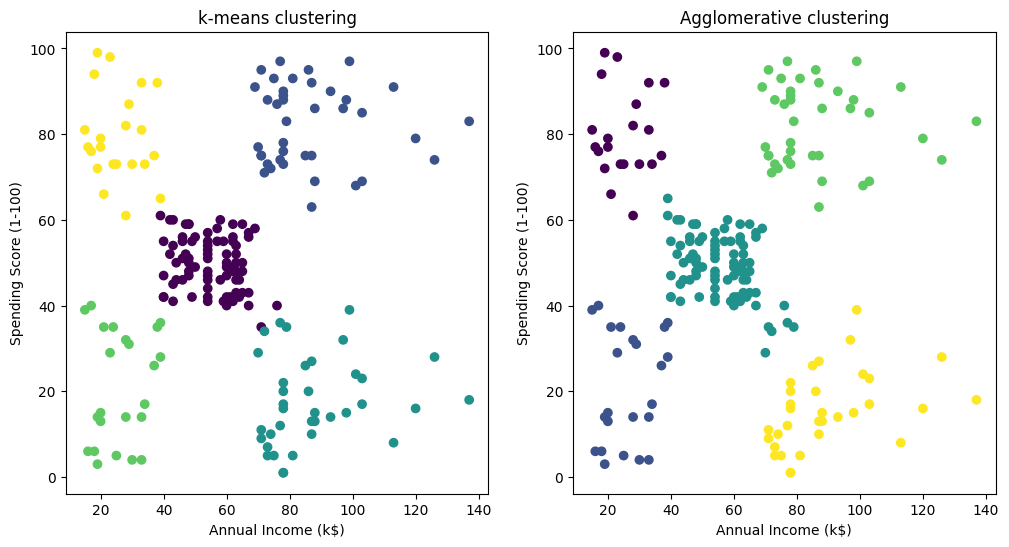

In [28]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(df_mall['Annual Income (k$)'],
            df_mall['Spending Score (1-100)'],
            c=df_mall['cluster'])
plt.title('k-means clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.subplot(1,2,2)
plt.scatter(df_mall['Annual Income (k$)'],
            df_mall['Spending Score (1-100)'],
            c=df_mall['cluster_Agglomerative'])
plt.title('Agglomerative clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()